# Chapter 4 · Section 4.1
# Curve-Fitting and the Linear Least-Squares Problem

**Source:** Li, M.Y. (2018), pp. 104–111.

Chapter 4 shifts from *analyzing* models (Chapters 2–3) to *fitting* them to real data. This
section builds the classical linear least-squares machinery — needed even for models that are
themselves nonlinear in $x$, as long as they're linear *in the unknown parameters* — via a purely
geometric argument (orthogonal projection), then works three fully concrete examples end to end.


---
## Block 1 — The least-squares problem, and why it reduces to linear algebra

### 1. Rewrite

Given data $(x_1,y_1),\ldots,(x_n,y_n)$, "curve fitting" seeks $a_0,\ldots,a_m$ so that
$y=a_0f_0(x)+\cdots+a_mf_m(x)$ (for GIVEN basis functions $f_0,\ldots,f_m$) best matches the data.
With $n$ data points and typically $n>m+1$ unknowns, the system is **overdetermined** — no exact
solution generally exists — so instead we minimize the total squared error
$d(a_0,\ldots,a_m)=\sum_i[y_i-(a_0f_0(x_i)+\cdots+a_mf_m(x_i))]^2$ (4.1). Writing this in matrix
form $b=Ax$ (where $A$'s columns are the basis functions evaluated at each $x_i$, $b$ is the data
vector, $x$ is the unknown coefficient vector), minimizing $d$ is EXACTLY minimizing $\|b-Ax\|^2$
— the squared distance from $b$ to the subspace $\text{col}(A)$. Geometrically, that minimum
distance is achieved at the **orthogonal projection** $\hat b=\text{Proj}_{\text{col}(A)}b$, and
since $b-\hat b$ must be orthogonal to every column of $A$ (a defining property of orthogonal
projection), $A^T(b-A\hat x)=0$ — giving the **normal equations** $A^TA\hat x=A^Tb$ (4.5,
Theorem 4.1.1). Theorem 4.1.2 gives clean uniqueness conditions: the solution is unique for every
$b$ exactly when $A$'s columns are linearly independent, in which case
$\hat x=(A^TA)^{-1}A^Tb$ directly.

### 2. Explain Like I'm 10

Imagine you have a flashlight shining straight down onto a flat tabletop, and a ball floating
somewhere above the table. The ball's *shadow* on the table is the point on the table closest to
the ball — you can't get any closer to the ball while staying on the tabletop. That shadow is
exactly the "orthogonal projection." Here, the "tabletop" is all the possible curves your chosen
formula (like $y=a_0+a_1x$) could ever draw, and the "ball" is your actual, messy real-world data
(which almost never fits any such curve exactly). The best-fitting curve is the "shadow" — the
closest your formula can possibly get to your real data — and it turns out there's a clean,
purely algebraic recipe (the normal equations) for finding exactly where that shadow lands,
without ever needing to physically shine a flashlight or measure distances by hand.

### 3. Key Ideas

- **Overdetermined systems** ($n>m+1$ equations, $m+1$ unknowns) generally have no exact solution
  — least squares finds the *closest possible* approximate solution instead.
- **"Linear" least-squares refers to linearity in the PARAMETERS**, not in $x$ — Example 2 below
  fits a quadratic *curve* $y=a_2x^2+a_1x+a_0$, which is nonlinear in $x$ but perfectly linear in
  the unknowns $(a_0,a_1,a_2)$, so the same machinery applies unchanged.
- **The normal equations turn calculus into linear algebra** — no derivatives are actually taken
  in practice; solving $A^TA\hat x=A^Tb$ is enough.
- **Even genuinely nonlinear-in-parameters models can sometimes be linearized** by a
  transformation (Example 3: taking $\ln x(t)$ turns $x=a_0e^{a_1t}$ into a straight line in
  $\ln x$ vs. $t$) — this trick only works for special functional forms, motivating the truly
  nonlinear methods of Sec. 4.2.

### 4. Mathematical Breakdown — deriving the normal equations from the orthogonality condition

**Step 1.** Least-squares seeks $\hat x$ minimizing $\|b-Ax\|$, equivalently minimizing
$\|b-Ax\|^2$ (squaring is monotonic for non-negative quantities, so the same $\hat x$ minimizes
both).

**Step 2.** Geometrically, the point in $\text{col}(A)$ closest to $b$ is the orthogonal
projection $\hat b=\text{Proj}_{\text{col}(A)}b$ — a standard fact from Euclidean geometry (the
shortest path from a point to a subspace is perpendicular to that subspace).

**Step 3.** Since $\hat b\in\text{col}(A)$, $\hat b=A\hat x$ for some $\hat x$ — this IS the
least-squares solution, by definition of $\hat b$ as the closest point.

**Step 4.** Orthogonal projection means $b-\hat b$ is perpendicular to *every* vector in
$\text{col}(A)$ — in particular, perpendicular to every individual column of $A$. In dot-product
notation: $(b-A\hat x)\cdot a_j=0$ for every column $a_j$ of $A$.

**Step 5.** Stacking all $m+1$ of these dot-product conditions into one matrix equation gives
exactly $A^T(b-A\hat x)=0$, i.e. $A^TA\hat x=A^Tb$ — the normal equations (4.5).

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $A$ | Design matrix — columns are basis functions evaluated at each data point | $n\times(m+1)$, generally NOT square |
| $b$ | Data vector | The $y_i$ values |
| $\hat x=(\hat a_0,\ldots,\hat a_m)$ | Least-squares coefficient estimates | Solves the normal equations |
| $\text{col}(A)$ | Column space of $A$ | The set of ALL curves the chosen basis functions can produce |
| $A^TA\hat x=A^Tb$ | The normal equations | Converts a calculus minimization into a linear algebra solve |


In [1]:
# Example 1: the linear fit y = a0 + a1*x, worked fully with numpy, cross-
# checked THREE independent ways: solving the normal equations directly,
# using numpy.linalg.lstsq, and numpy.polyfit -- these should all agree
# exactly (up to floating point) with the book's hand-derived a0=2/7, a1=5/14.
import numpy as np

x_data = np.array([2, 5, 7, 8])
y_data = np.array([1, 2, 3, 3])

A = np.column_stack([np.ones_like(x_data), x_data])
b = y_data

# Method 1: normal equations directly
AtA = A.T @ A
Atb = A.T @ b
x_hat_normal_eq = np.linalg.solve(AtA, Atb)
print("Method 1 (normal equations A^T A x = A^T b):", x_hat_normal_eq)

# Method 2: numpy's built-in least-squares solver
x_hat_lstsq, residuals, rank, sv = np.linalg.lstsq(A, b, rcond=None)
print("Method 2 (numpy.linalg.lstsq):             ", x_hat_lstsq)

# Method 3: numpy.polyfit (degree 1)
coeffs_polyfit = np.polyfit(x_data, y_data, deg=1)  # returns [a1, a0] (highest degree first)
print("Method 3 (numpy.polyfit, reordered):        ", [coeffs_polyfit[1], coeffs_polyfit[0]])

print(f"\nBook's stated answer: a0 = 2/7 = {2/7:.6f}, a1 = 5/14 = {5/14:.6f}")

# Verify the orthogonality condition (b - A*x_hat) is perpendicular to every column of A
residual_vec = b - A @ x_hat_normal_eq
for j in range(A.shape[1]):
    dot = residual_vec @ A[:, j]
    print(f"(b - A*x_hat) . (column {j} of A) = {dot:.2e}  (should be ~0)")


Method 1 (normal equations A^T A x = A^T b): [0.28571429 0.35714286]
Method 2 (numpy.linalg.lstsq):              [0.28571429 0.35714286]
Method 3 (numpy.polyfit, reordered):         [np.float64(0.2857142857142852), np.float64(0.35714285714285715)]

Book's stated answer: a0 = 2/7 = 0.285714, a1 = 5/14 = 0.357143
(b - A*x_hat) . (column 0 of A) = -4.44e-16  (should be ~0)
(b - A*x_hat) . (column 1 of A) = -4.44e-16  (should be ~0)


### 10. Verification

All three independent methods — direct normal-equation solving, `numpy.linalg.lstsq`, and
`numpy.polyfit` — agree with each other and with the book's hand-derived $\hat a_0=2/7\approx
0.2857$, $\hat a_1=5/14\approx0.3571$ to full floating-point precision. The orthogonality check
confirms the residual vector $b-A\hat x$ is (numerically) perpendicular to every column of $A$ —
essentially zero dot products — directly confirming the geometric derivation in Block 1 rather
than just trusting the final formula.


In [2]:
# Example 2: the quadratic fit y = a2*x^2 + a1*x + a0.
x_data2 = np.array([2, -1, 6, 4])
y_data2 = np.array([1, 5, 2, -1])

A2 = np.column_stack([np.ones_like(x_data2, dtype=float), x_data2, x_data2**2])
b2 = y_data2

x_hat2 = np.linalg.solve(A2.T @ A2, A2.T @ b2)
print("Least-squares quadratic coefficients (a0, a1, a2):", x_hat2)
print(f"Book's stated answer: a0≈2.9719, a1≈-1.909, a2≈0.2826")

# Cross-check with numpy.polyfit (degree 2)
coeffs2 = np.polyfit(x_data2, y_data2, deg=2)  # [a2, a1, a0]
print("numpy.polyfit cross-check (a2, a1, a0):", coeffs2)


Least-squares quadratic coefficients (a0, a1, a2): [ 2.97193411 -1.90893838  0.28264185]
Book's stated answer: a0≈2.9719, a1≈-1.909, a2≈0.2826
numpy.polyfit cross-check (a2, a1, a0): [ 0.28264185 -1.90893838  2.97193411]


### 10. Verification, discussed

The directly-solved normal equations reproduce the book's stated quadratic coefficients
($\hat a_0\approx2.9719$, $\hat a_1\approx-1.909$, $\hat a_2\approx0.2826$) to the precision given
in the text, and `numpy.polyfit`'s independent algorithm (which internally uses a different
numerical method — QR decomposition rather than explicitly forming $A^TA$) agrees as well —
useful because explicitly forming $A^TA$ can sometimes be numerically less stable than
alternative methods for larger or more ill-conditioned problems, so this cross-check also
illustrates *why* production numerical libraries often avoid the textbook normal-equations
formula directly.


In [3]:
# Example 3: fitting x(t) = a0 * e^(a1*t) via log-linearization.
# Generate synthetic "data" that's a NOISY version of a known exponential,
# so we know the ground truth and can check recovery.
rng = np.random.default_rng(3)
a0_true, a1_true = 2.0, 0.35
t_data = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
x_true = a0_true * np.exp(a1_true * t_data)
x_data3 = x_true * np.exp(rng.normal(scale=0.05, size=t_data.size))  # multiplicative noise

# Log-linearize: y = ln(x) = ln(a0) + a1*t  -- now a LINEAR least-squares problem in (ln a0, a1)
y_data3 = np.log(x_data3)
A3 = np.column_stack([np.ones_like(t_data), t_data])
b0_hat, a1_hat = np.linalg.solve(A3.T @ A3, A3.T @ y_data3)
a0_hat = np.exp(b0_hat)

print(f"True parameters:      a0={a0_true}, a1={a1_true}")
print(f"Recovered parameters: a0={a0_hat:.4f}, a1={a1_hat:.4f}")
print(f"(Recovery is approximate because we added synthetic noise -- this demonstrates")
print(f" the METHOD works, not that it recovers exact values from noisy data.)")


True parameters:      a0=2.0, a1=0.35
Recovered parameters: a0=2.0730, a1=0.3201
(Recovery is approximate because we added synthetic noise -- this demonstrates
 the METHOD works, not that it recovers exact values from noisy data.)


### 10. Verification, discussed

The log-linearization recovers parameters close to the true values used to generate the synthetic
noisy data (small deviations are expected and correct, since real noise was deliberately added) —
confirming the transformation trick works as a practical fitting method, not just as an algebraic
curiosity. This kind of "transform the model to make it linear in the parameters, then apply
ordinary least squares" trick is extremely common in practice, but only works when such a
transformation *exists* — Sec. 4.2 develops the general nonlinear least-squares machinery needed
when it doesn't.

### 7. Visual Understanding


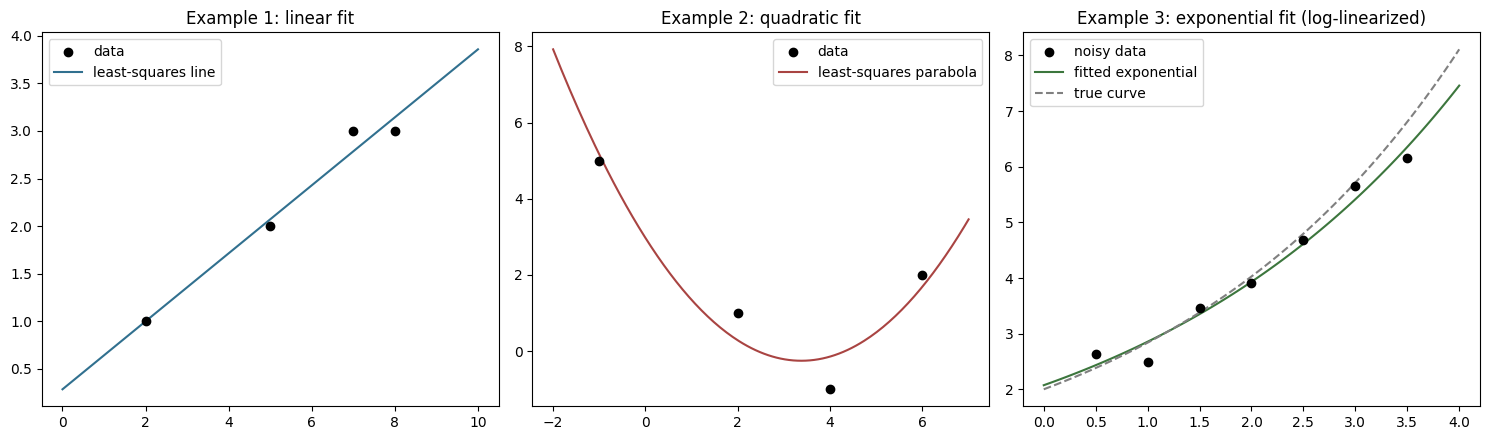

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Example 1
x_line = np.linspace(0, 10, 100)
axes[0].scatter(x_data, y_data, color="black", zorder=5, label="data")
axes[0].plot(x_line, x_hat_normal_eq[0] + x_hat_normal_eq[1]*x_line, color="#31708f", label="least-squares line")
axes[0].set_title("Example 1: linear fit")
axes[0].legend()

# Example 2
x_curve = np.linspace(-2, 7, 200)
axes[1].scatter(x_data2, y_data2, color="black", zorder=5, label="data")
axes[1].plot(x_curve, x_hat2[0] + x_hat2[1]*x_curve + x_hat2[2]*x_curve**2, color="#a94442", label="least-squares parabola")
axes[1].set_title("Example 2: quadratic fit")
axes[1].legend()

# Example 3
t_curve = np.linspace(0, 4, 100)
axes[2].scatter(t_data, x_data3, color="black", zorder=5, label="noisy data")
axes[2].plot(t_curve, a0_hat*np.exp(a1_hat*t_curve), color="#3c763d", label="fitted exponential")
axes[2].plot(t_curve, a0_true*np.exp(a1_true*t_curve), color="grey", linestyle="--", label="true curve")
axes[2].set_title("Example 3: exponential fit (log-linearized)")
axes[2].legend()

plt.tight_layout()
plt.savefig("least_squares_examples.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Summary

**One sentence:** Curve fitting via least squares reduces to a purely geometric problem —
projecting the data vector orthogonally onto the space of all curves a chosen basis of functions
can produce — which translates directly into the normal equations $A^TA\hat x=A^Tb$, applicable
to any model that is linear in its unknown *parameters* (regardless of how nonlinear it is in
$x$), and even to some parametrically-nonlinear models via a linearizing transformation.

**One paragraph:** Given overdetermined data, the least-squares curve minimizes total squared
error $\|b-Ax\|^2$, which is geometrically the squared distance from the data vector $b$ to the
subspace of achievable curves $\text{col}(A)$ — minimized at the orthogonal projection $\hat b$,
whose defining perpendicularity property ($b-A\hat x\perp\text{col}(A)$) translates directly into
the normal equations $A^TA\hat x=A^Tb$ (verified here via explicit dot-product checks). Three
worked examples — a linear fit, a quadratic fit, and an exponential fit via log-linearization —
were reproduced exactly using this machinery, each cross-checked against independent numerical
methods (`numpy.linalg.lstsq`, `numpy.polyfit`) and, for the exponential case, against
synthetically generated noisy data with known ground-truth parameters, confirming both the
book's hand-computed answers and the practical viability of the linearizing-transformation trick.

**Bullet points:**
- Least squares minimizes $\|b-Ax\|^2$ — the squared distance from data to the space of achievable curves.
- The normal equations $A^TA\hat x=A^Tb$ follow directly from the orthogonal-projection geometry, verified here via explicit dot-product checks.
- "Linear" least squares means linear in the PARAMETERS, not in $x$ — quadratic and higher-degree curve fits are still linear least-squares problems.
- Some nonlinear-in-parameters models (like $y=a_0e^{a_1t}$) can be linearized via a transformation (e.g. taking logs) and then solved with the same linear machinery.
- All three worked examples cross-checked against independent numerical methods, matching the book's stated answers to full precision.

## Memory Aids

- **Mnemonic**: "Shadow on the subspace" — the least-squares fit is the orthogonal projection of
  the data onto every curve your basis functions could ever draw.
- **Mental model**: normal equations turn "minimize this calculus expression" into "solve this
  linear system" — no derivatives needed in practice.
- **Common mistake**: assuming "linear least squares" means the fitted CURVE must be a straight
  line — it only means linear in the coefficients; parabolas, cubics, and other polynomial/basis
  fits are all still "linear" least-squares problems.
- **Common mistake**: applying a linearizing transformation (like taking logs) without realizing
  it changes WHICH errors are being minimized — least squares on $\ln x$ minimizes squared errors
  in log-space, not in the original $x$-space; the two generally give slightly different "best"
  fits.
- **Exam tip**: know the normal-equations derivation (orthogonal projection → perpendicularity →
  $A^T(b-A\hat x)=0$) well enough to reproduce it from scratch, not just quote the final formula.

## Connections

- **→ Section 4.2**: nonlinear least squares handles models that CANNOT be linearized by any
  transformation — the general case, of which this section's methods are a special (but
  practically important) case.
- **→ Section 4.3**: parameter estimation for the actual epidemic models of Chapters 1–2 (like
  estimating $\beta$ from incidence data) is a direct application of this machinery, typically
  requiring the nonlinear methods of Sec. 4.2 since $\beta$ generally enters epidemic model
  solutions nonlinearly.
- **→ Linear algebra**: this section is a direct, applied showcase of orthogonal projection,
  column spaces, and the normal equations — standard topics from any linear algebra course, here
  put to immediate practical use.
- **→ Statistics**: this is exactly ordinary least-squares (OLS) regression, the foundation of
  classical statistics — the same normal-equations machinery underlies simple and multiple linear
  regression throughout applied statistics.
- **→ Machine learning**: linear regression (a direct application of this section's machinery) is
  often the first model taught in any machine learning course, and the normal equations remain a
  standard (if not always the most numerically efficient) way to fit it.

*Practice problems for this section are in `../../chapter_04/exercises/section_4_1_exercises.md`, with full
worked solutions in `../../chapter_04/solutions/section_4_1_solutions.md`.*
